In [1]:
# Import necessary libraries
import pandas as pd
import pyspark.sql.functions as F
from pyspark.sql import SparkSession
from kedro.io import DataCatalog
import json
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, LongType, TimestampType
import pandas_ta as ta
from pyspark.sql.functions import col, date_sub, current_date, to_timestamp

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import mlflow
import mlflow.keras
import numpy as np
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import mplfinance as mpf

In [2]:
%load_ext kedro.ipython

The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


In [3]:
catalog.list()


[
    'access_token',
    'access_kinesis',
    'kinesis_client',
    'validated_access_token',
    'validated_websocket_data_NSE_INDEX_Nifty_50',
    'raw_data_NSE_INDEX_Nifty_Bank_1minute',
    'transformed_data_NSE_INDEX_Nifty_Bank_1minute@csv',
    'indicators_data_NSE_INDEX_Nifty_Bank_1minute@csv',
    'feature_engineering_data_NSE_INDEX_Nifty_Bank_1minute@csv',
    'feature_engineering_data_NSE_INDEX_Nifty_Bank_1minute@spark',
    'raw_data_NSE_INDEX_Nifty_Bank_30minute',
    'transformed_data_NSE_INDEX_Nifty_Bank_30minute@csv',
    'indicators_data_NSE_INDEX_Nifty_Bank_30minute@csv',
    'feature_engineering_data_NSE_INDEX_Nifty_Bank_30minute@csv',
    'feature_engineering_data_NSE_INDEX_Nifty_Bank_30minute@spark',
    'raw_data_NSE_INDEX_Nifty_Bank_day',
    'transformed_data_NSE_INDEX_Nifty_Bank_day@csv',
    'indicators_data_NSE_INDEX_Nifty_Bank_day@csv',
    'feature_engineering_data_NSE_INDEX_Nifty_Bank_day@csv',
    'feature_engineering_data_NSE_INDEX_Nifty_Bank_day@spark

[08/03/24 20:46:28] INFO     Loading data from                                                  ]8;id=641995;file:///opt/anaconda3/envs/stock_AI/lib/python3.8/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=891775;file:///opt/anaconda3/envs/stock_AI/lib/python3.8/site-packages/kedro/io/data_catalog.py#508\508]8;;\
                             train_data_20w_4w_NSE_INDEX_Nifty_Bank_30minute_s3@csv                                
                             (CSVDataset)...                                                                       

[08/03/24 20:46:30] INFO     Loading data from                                                  ]8;id=883373;file:///opt/anaconda3/envs/stock_AI/lib/python3.8/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=6770;file:///opt/anaconda3/envs/stock_AI/lib/python3.8/site-packages/kedro/io/data_catalog.py#508\508]8;;\
                             test_data_20w_4w_NSE_INDEX_Nifty_Bank_30minute_s3@csv                                 
                             (CSVDataset)...                                                                       

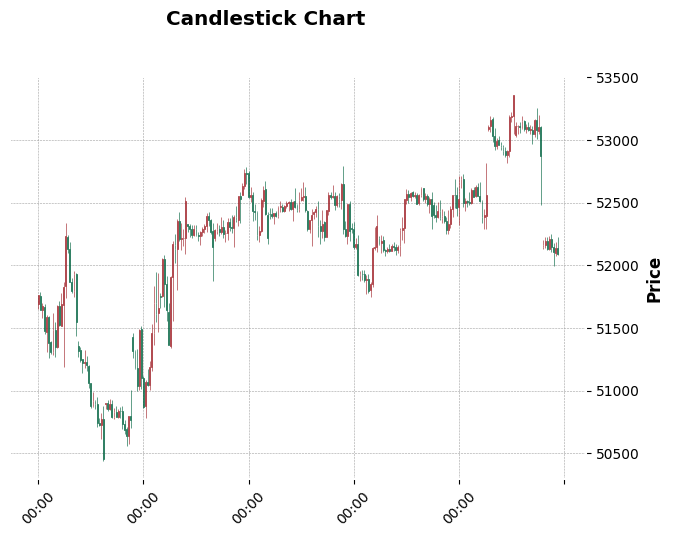

Length of test data: 248
Test data statistics:
               High           Low         Close  Volume          Open  \
count    248.000000    248.000000    248.000000   248.0    248.000000   
mean   52241.839315  52064.448387  52157.205242     0.0  52155.845565   
std      598.256955    624.165904    607.978330     0.0    616.960296   
min    50707.750000  50438.300000  50636.050000     0.0  50456.100000   
25%    51955.562500  51750.750000  51878.987500     0.0  51889.050000   
50%    52383.400000  52226.200000  52295.450000     0.0  52294.750000   
75%    52583.400000  52445.587500  52514.762500     0.0  52523.275000   
max    53357.700000  53143.400000  53190.850000     0.0  53357.700000   

       weekday_num  month_num  is_monthly_expiration           SMA  \
count   248.000000      248.0                  248.0    248.000000   
mean      1.995968        7.0                    0.0  52148.982782   
std       1.452341        0.0                    0.0    585.625656   
min       0.000

In [10]:
# train_data_df = catalog.load("train_data_20w_4w_NSE_INDEX_Nifty_Bank_day_s3@csv")
# test_data_df = catalog.load("test_data_20w_4w_NSE_INDEX_Nifty_Bank_day_s3@csv")
train_data_df = catalog.load("train_data_20w_4w_NSE_INDEX_Nifty_Bank_30minute_s3@csv")
test_data_df = catalog.load("test_data_20w_4w_NSE_INDEX_Nifty_Bank_30minute_s3@csv")

# # Assuming train_data_df is your DataFrame
# train_data_stats = train_data_df.describe(include='all')
# test_data_stats = test_data_df.describe(include='all')


# Convert the index to datetime if necessary
if not pd.api.types.is_datetime64_any_dtype(test_data_df.index):
    test_data_df.index = pd.to_datetime(test_data_df.index)

# Assuming your data has 'open', 'high', 'low', 'close' columns
# Otherwise, adjust the column names as needed
mpf.plot(test_data_df, type='candle', style='charles', title='Candlestick Chart', ylabel='Price')

# Display the length and first few rows of the test data
print("Length of test data:", len(test_data_df))
print("Test data statistics:")
print(test_data_df.describe())


Length of test data: 1204
Test data statistics:
               High           Low         Close  Volume          Open  \
count   1204.000000   1204.000000   1204.000000  1204.0   1204.000000   
mean   48401.908223  48227.815615  48319.313746     0.0  48316.817068   
std     1702.268653   1699.321243   1698.749270     0.0   1702.814853   
min    45108.400000  44860.750000  45070.600000     0.0  45014.650000   
25%    47176.487500  46983.475000  47103.787500     0.0  47096.275000   
50%    48040.875000  47874.575000  47965.925000     0.0  47959.575000   
75%    49245.675000  49007.687500  49104.000000     0.0  49114.400000   
max    53180.750000  52900.750000  53100.100000     0.0  53100.500000   

       weekday_num    month_num  is_monthly_expiration           SMA  \
count  1204.000000  1204.000000            1204.000000   1204.000000   
mean      2.030731     4.215116               0.010797  48344.918426   
std       1.411820     1.372235               0.103391   1694.064439   
min   

[08/03/24 20:35:02] WARNING  /opt/anaconda3/envs/stock_AI/lib/python3.8/site-packages/mplfinance/_a ]8;id=568886;file:///opt/anaconda3/envs/stock_AI/lib/python3.8/warnings.py\warnings.py]8;;\:]8;id=172621;file:///opt/anaconda3/envs/stock_AI/lib/python3.8/warnings.py#109\109]8;;\
                             rg_validators.py:84: UserWarning:                                                     
                                                                                                                   
                              =================================================================                    
                                                                                                                   
                                WARNING: YOU ARE PLOTTING SO MUCH DATA THAT IT MAY NOT BE                          
                                         POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)                        
                                For more information see:                                                          
                                -                                                                                  
                             https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data                  
                                                                                                                   
                                TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`                         
                                OR set kwarg `warn_too_much_data=N` where N is an integer                          
                                LARGER than the number of data points you want to plot.                            
                                                                                                                   
                              ================================================================                     
                               warnings.warn('\n\n                                                                 
                             ================================================================= '+                  
                                                                                                                   

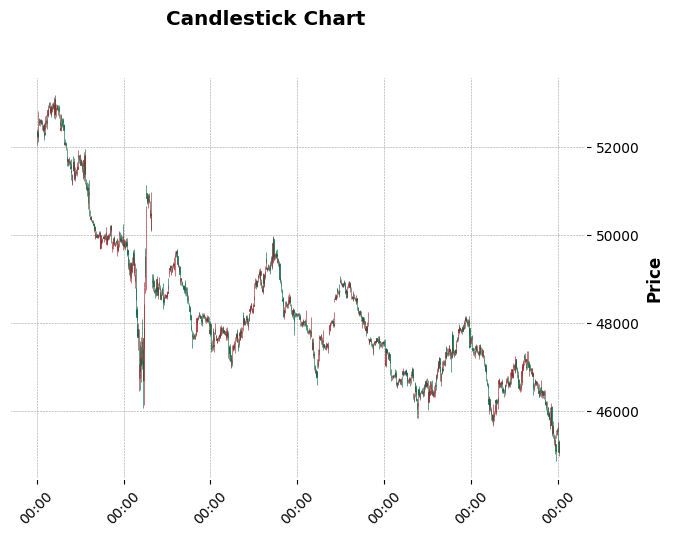

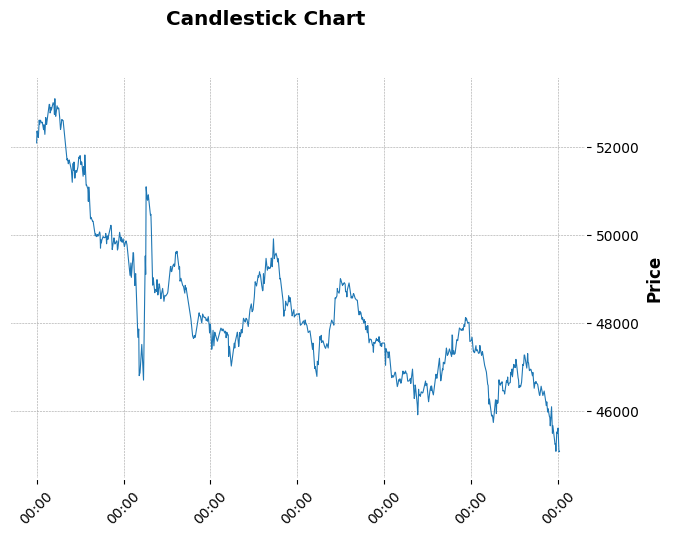

In [5]:
# Convert the index to datetime if necessary
if not pd.api.types.is_datetime64_any_dtype(train_data_df.index):
    train_data_df.index = pd.to_datetime(train_data_df.index)

# Display the length and first few rows of the test data
print("Length of test data:", len(train_data_df))
print("Test data statistics:")
print(train_data_df.describe())

# Assuming your data has 'open', 'high', 'low', 'close' columns
# Otherwise, adjust the column names as needed
mpf.plot(train_data_df, type='candle', style='charles', title='Candlestick Chart', ylabel='Price')

# Otherwise, adjust the column names as needed
mpf.plot(train_data_df, type='line', style='charles', title='Candlestick Chart', ylabel='Price')

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
import mlflow
import mlflow.keras


# Data preprocessing function
def preprocess_data(df, feature_columns, target_columns, scaler=None):
    # Extract features and targets
    X = df[feature_columns].values
    y = df[target_columns].values
    
    # Normalize the features
    if scaler is None:
        scaler = MinMaxScaler()
        X = scaler.fit_transform(X)
    else:
        X = scaler.transform(X)
    
    return X, y, scaler

# Prepare the dataset function
def prepare_dataset(train_df, test_df, feature_columns, target_columns, timestep=60):
    # Preprocess training data
    X_train, y_train, scaler = preprocess_data(train_df, feature_columns, target_columns)
    
    # Preprocess testing data using the same scaler
    X_test, y_test, _ = preprocess_data(test_df, feature_columns, target_columns, scaler=scaler)
    
    # Reshape X to be [samples, timesteps, features]
    X_train_reshaped, y_train_reshaped = reshape_to_sequences(X_train, y_train, timestep)
    X_test_reshaped, y_test_reshaped = reshape_to_sequences(X_test, y_test, timestep)
    
    return X_train_reshaped, y_train_reshaped, X_test_reshaped, y_test_reshaped

# Reshape the data into sequences
def reshape_to_sequences(X, y, timestep):
    X_seq, y_seq = [], []
    for i in range(len(X) - timestep):
        X_seq.append(X[i:i+timestep])
        y_seq.append(y[i+timestep])
    return np.array(X_seq), np.array(y_seq)

# Define an improved LSTM model
def create_improved_model(input_shape):
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True, kernel_regularizer=l2(0.01)), input_shape=input_shape),
        Dropout(0.5),
        BatchNormalization(),
        Bidirectional(LSTM(180, kernel_regularizer=l2(0.01))),
        Dropout(0.5),
        BatchNormalization(),
        Dense(2, activation='linear')
    ])
    
    # Adam optimizer with learning rate scheduling
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

# Training and evaluation function
def train_and_evaluate_model(X_train, y_train, X_test, y_test):
    input_shape = (X_train.shape[1], X_train.shape[2])
    model = create_improved_model(input_shape)
    
    # Callbacks for early stopping and learning rate reduction
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ]
    
    # Start an MLflow run
    with mlflow.start_run():
        # Train the model
        history = model.fit(
            X_train, y_train,
            epochs=50,
            batch_size=64,
            validation_data=(X_test, y_test),
            callbacks=callbacks
        )
        
        # Log the model
        mlflow.keras.log_model(model, "improved_lstm_model")
        mlflow.log_params({"model_type": "Bidirectional LSTM", "epochs": 50, "batch_size": 64})
        
        # Log final training and validation loss
        final_train_loss = history.history['loss'][-1]
        final_val_loss = history.history['val_loss'][-1]
        mlflow.log_metrics({"final_train_loss": final_train_loss, "final_val_loss": final_val_loss})
        
        # Predictions
        y_pred = model.predict(X_test)
        
        # Evaluation metrics
        mse = np.mean((y_pred - y_test) ** 2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(y_pred - y_test))
        
        mlflow.log_metrics({"mse": mse, "rmse": rmse, "mae": mae})
        
        # Print results
        print(f"Final Training Loss: {final_train_loss}")
        print(f"Final Validation Loss: {final_val_loss}")
        print(f"Mean Squared Error (MSE) on Test Set: {mse}")
        print(f"Root Mean Squared Error (RMSE) on Test Set: {rmse}")
        print(f"Mean Absolute Error (MAE) on Test Set: {mae}")
        
        # Plot and save the training loss and validation loss
        plt.figure(figsize=(10, 5))
        plt.plot(history.history['loss'], label='Train Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title('Model Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.savefig('model_loss_plot.png')
        mlflow.log_artifact('model_loss_plot.png')
        plt.show()
        
        # Plot and save predictions vs actuals
        plt.figure(figsize=(10, 5))
        plt.plot(y_test[:, 0], label='Actual High')
        plt.plot(y_pred[:, 0], label='Predicted High')
        plt.title('Actual vs Predicted High Prices')
        plt.xlabel('Sample Index')
        plt.ylabel('Price')
        plt.legend()
        plt.grid(True)
        plt.savefig('high_prices_plot.png')
        mlflow.log_artifact('high_prices_plot.png')
        plt.show()
        
        plt.figure(figsize=(10, 5))
        plt.plot(y_test[:, 1], label='Actual Low')
        plt.plot(y_pred[:, 1], label='Predicted Low')
        plt.title('Actual vs Predicted Low Prices')
        plt.xlabel('Sample Index')
        plt.ylabel('Price')
        plt.legend()
        plt.grid(True)
        plt.savefig('low_prices_plot.png')
        mlflow.log_artifact('low_prices_plot.png')
        plt.show()



In [19]:
# Define feature columns and target columns
feature_columns = ['High', 'Low', 'Open', 'Close', 'weekday_num', 'EMA', 'RSI', 'SMA']
target_columns = ['High_next', 'Low_next']


In [20]:
x_train, y_train, x_test, y_test = prepare_dataset(train_data_df, test_data_df, feature_columns, target_columns)

Epoch 1/50
18/18 [==============================] - 12s 368ms/step - loss: 2313627648.0000 - val_loss: 2748993536.0000 - lr: 0.0010
Epoch 2/50
18/18 [==============================] - 5s 306ms/step - loss: 2313562368.0000 - val_loss: 2748369920.0000 - lr: 0.0010
Epoch 3/50
18/18 [==============================] - 6s 308ms/step - loss: 2313462016.0000 - val_loss: 2747415296.0000 - lr: 0.0010
Epoch 4/50
18/18 [==============================] - 5s 306ms/step - loss: 2313312768.0000 - val_loss: 2746106112.0000 - lr: 0.0010
Epoch 5/50
18/18 [==============================] - 6s 320ms/step - loss: 2313111552.0000 - val_loss: 2744429568.0000 - lr: 0.0010
Epoch 6/50
18/18 [==============================] - 6s 323ms/step - loss: 2312852480.0000 - val_loss: 2743002368.0000 - lr: 0.0010
Epoch 7/50
18/18 [==============================] - 6s 312ms/step - loss: 2312531712.0000 - val_loss: 2739577088.0000 - lr: 0.0010
Epoch 8/50
18/18 [==============================] - 7s 367ms/step - loss: 23121507

2024/08/03 21:09:32 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


[08/03/24 21:10:06] WARNING  /opt/anaconda3/envs/stock_AI/lib/python3.8/site-packages/_distutils_ha ]8;id=84237;file:///opt/anaconda3/envs/stock_AI/lib/python3.8/warnings.py\warnings.py]8;;\:]8;id=356067;file:///opt/anaconda3/envs/stock_AI/lib/python3.8/warnings.py#109\109]8;;\
                             ck/__init__.py:26: UserWarning: Setuptools is replacing distutils.                    
                               warnings.warn("Setuptools is replacing distutils.")                                 
                                                                                                                   

2024/08/03 21:10:06 WARNING mlflow.models.model: Input example should be provided to infer model signature if the model signature is not provided when logging the model.


6/6 [==============================] - 2s 72ms/step
Final Training Loss: 2244536576.0
Final Validation Loss: 2454124032.0
Mean Squared Error (MSE) on Test Set: 2454124185.2016435
Root Mean Squared Error (RMSE) on Test Set: 49539.11772732376
Mean Absolute Error (MAE) on Test Set: 49538.12998540351


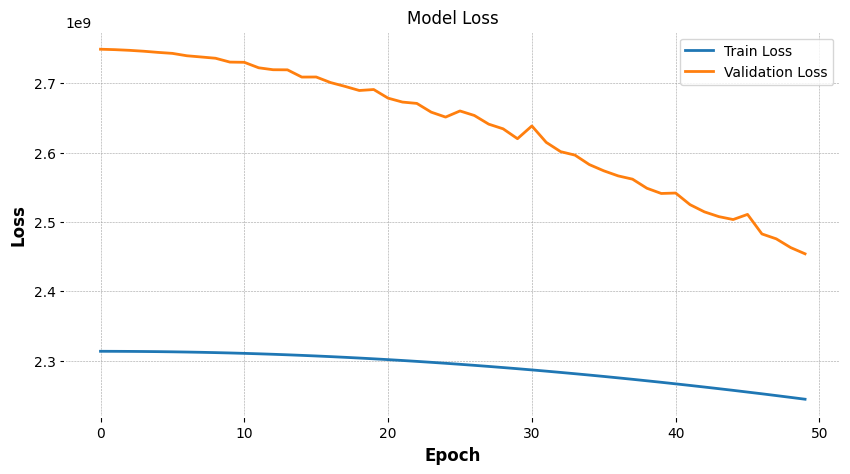

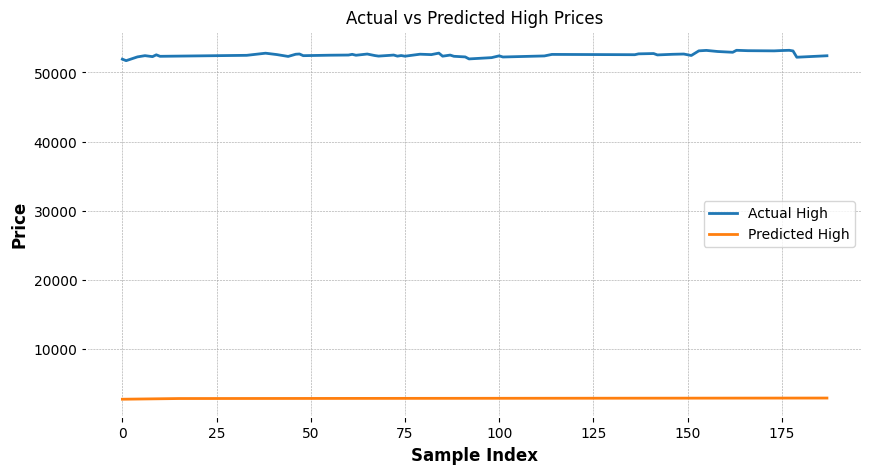

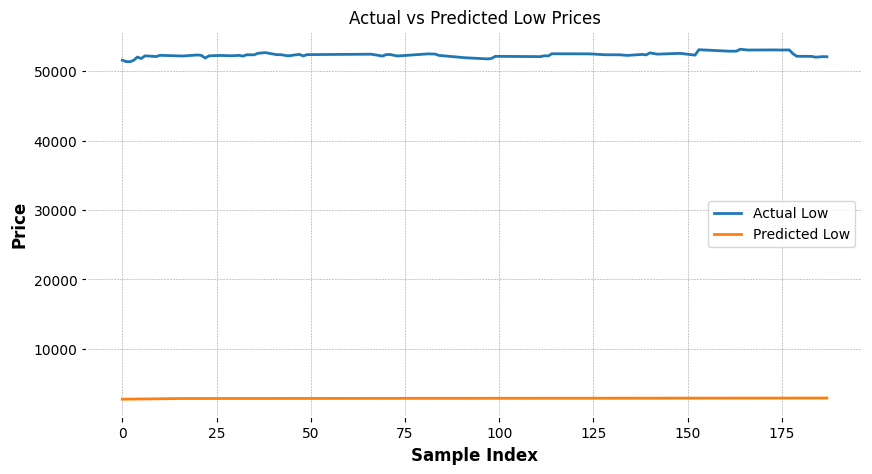

In [21]:
train_and_evaluate_model(x_train, y_train, x_test, y_test)